Classification, Gaussian Naive Bayes, LDA, QDA, ROC curve

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = np.genfromtxt("galaxyquasar.csv", delimiter=",", names=True, dtype=None, encoding='utf-8')

In [4]:
print(data)

[(18.97213, 18.53676, 18.5828 , 18.34936, 18.29215, 'QSO', 0.5228189 , 1.547483e-04)
 (19.24592, 17.47646, 16.47817, 16.04472, 15.68851, 'GALAXY', 0.1228459 , 2.816076e-05)
 (19.43536, 17.70268, 16.91565, 16.58327, 16.39128, 'GALAXY', 0.        , 0.000000e+00)
 ...
 (18.62718, 17.30876, 16.87371, 16.62399, 16.42296, 'GALAXY', 0.05442934, 8.433598e-06)
 (19.5514 , 18.27711, 17.62101, 17.21947, 17.03347, 'GALAXY', 0.1125709 , 9.286238e-06)
 (18.80772, 17.75751, 17.405  , 17.2165 , 17.12295, 'GALAXY', 0.04365238, 7.415751e-06)]


In [5]:
print(data.dtype.names)

('u', 'g', 'r', 'i', 'z', 'class', 'z1', 'zerr')


In [6]:
ug = [x[0] - x[1] for x in data]
gr = [x[1] - x[2] for x in data]
ri = [x[2] - x[3] for x in data]
iz = [x[3] - x[4] for x in data]

In [7]:
print(len(ug))
lab = [0 if x[5] == "GALAXY" else 1 for x in data]

50000


In [8]:
data = np.stack((ug, gr, ri, iz, lab), axis=1)
gal = np.array([x for x in data if x[4]==0])
qua = np.array([x for x in data if x[4]==1])

In [9]:
print(data)

[[ 0.43537 -0.04604  0.23344  0.05721  1.     ]
 [ 1.76946  0.99829  0.43345  0.35621  0.     ]
 [ 1.73268  0.78703  0.33238  0.19199  0.     ]
 ...
 [ 1.31842  0.43505  0.24972  0.20103  0.     ]
 [ 1.27429  0.6561   0.40154  0.186    0.     ]
 [ 1.05021  0.35251  0.1885   0.09355  0.     ]]


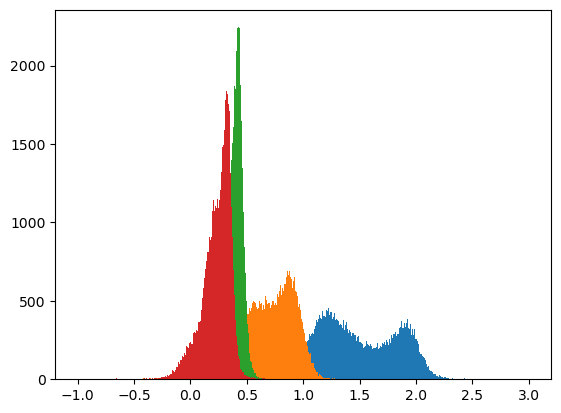

In [10]:
b = np.linspace(-1, 3, 500)
plt.hist(data[:,0], bins=b)
plt.hist(data[:,1], bins=b)
plt.hist(data[:,2], bins=b)
plt.hist(data[:,3], bins=b);

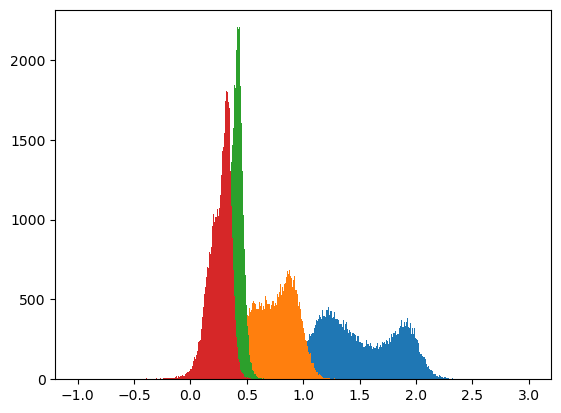

In [11]:
plt.hist(gal[:,0], bins=b)
plt.hist(gal[:,1], bins=b)
plt.hist(gal[:,2], bins=b)
plt.hist(gal[:,3], bins=b);

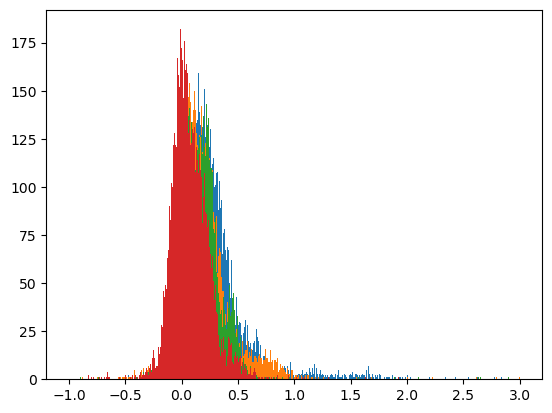

In [12]:
plt.hist(qua[:,0], bins=b)
plt.hist(qua[:,1], bins=b)
plt.hist(qua[:,2], bins=b)
plt.hist(qua[:,3], bins=b);

In [13]:
np.random.shuffle(data)
train = 40000
validation = 50000 - train
data_train = data[:train]
data_validation = data[-validation:]

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve

In [31]:
#print(data_train[:,0].reshape(-1, 1))
#gnb.fit error
#ValueError: Expected 2D array, got 1D array instead:
#array=[1.36886 1.22706 0.39728 ... 1.23249 1.58784 1.56773].
#Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

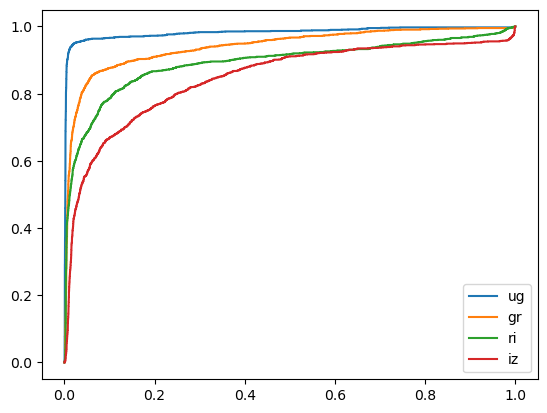

In [30]:
gnb = GaussianNB()
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    #print(thresh)       #2-1-0.999-....-0.8-....0.7-....
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()

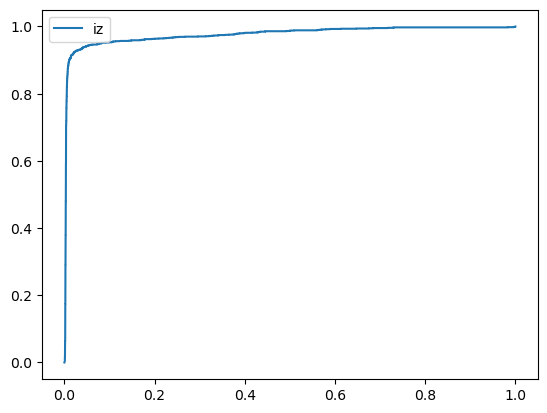

In [ ]:
#all columns together
gnb = GaussianNB()
lab = ["ug", "gr", "ri", "iz"]

gnb.fit(data_train[:, (0, 1, 2, 3)], data_train[:,4])
y_prob = gnb.predict_proba(data_validation[:, (0, 1, 2, 3)])[:,1]
#print(y_prob)

fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
#print(thresh)       #2-1-0.999-....-0.8-....0.7-....
plt.plot(fpr, tpr, label=lab[i])

plt.legend()

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

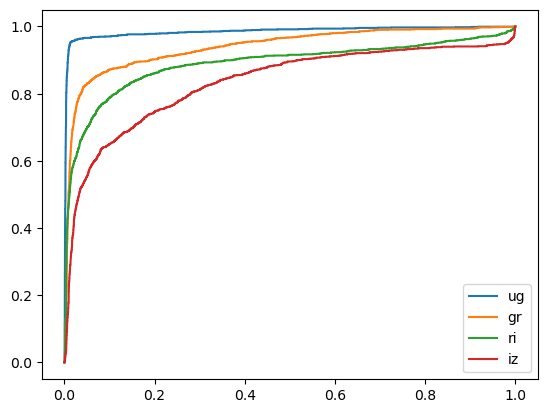

In [18]:
gnb = LDA()                     #è rimasto gnb per copia incolla
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()

#almeno qui il verde va un pochino sotto il rosso

In [19]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

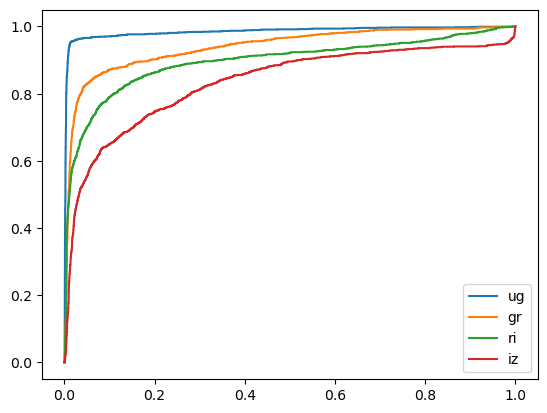

In [20]:
gnb = QDA()
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()

In [21]:
from sklearn.neighbors import KNeighborsClassifier

[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]
[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]
[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]
[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]


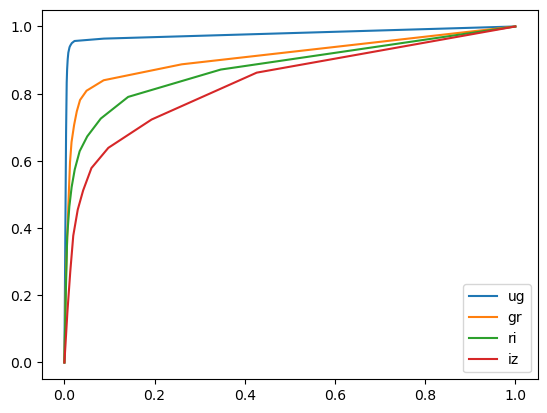

In [22]:
gnb = KNeighborsClassifier(10)
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    print(thresh)
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()

In [23]:
x_train = np.array(data_train[:,(0, 1, 2, 3)])
y_train = np.array(data_train[:,4])
x_validation = np.array(data_validation[:,(0, 1, 2, 3)])
y_validation = np.array(data_validation[:,4])
#clean up because I need to rescale the data

#ug_train, gr_train, ri_train, iz_train = np.hsplit(x_train, 4)
#ug_validation, gr_validation, ri_validation, iz_validation = np.hsplit(x_validation, 4)

In [24]:
#print(x_train)
#print(ug_train)         #ug_train is already in the right format (already .reshape(-1,1)), non so se è necessario

In [25]:
#peccato che devo usare flatten ora
#ug_train = np.array([(x-np.mean(ug_train.flatten()))/np.std(ug_train.flatten()) for x in ug_train.flatten()]).reshape(-1,1)
#gr_train = np.array([(x-np.mean(gr_train.flatten()))/np.std(gr_train.flatten()) for x in gr_train.flatten()]).reshape(-1,1)
#ri_train = np.array([(x-np.mean(ri_train.flatten()))/np.std(ri_train.flatten()) for x in ri_train.flatten()]).reshape(-1,1)
#iz_train = np.array([(x-np.mean(iz_train.flatten()))/np.std(iz_train.flatten()) for x in iz_train.flatten()]).reshape(-1,1)

#ug_validation = np.array([(x-np.mean(ug_validation.flatten()))/np.std(ug_validation.flatten()) for x in ug_validation.flatten()]).reshape(-1,1)
#gr_validation = np.array([(x-np.mean(gr_validation.flatten()))/np.std(gr_validation.flatten()) for x in gr_validation.flatten()]).reshape(-1,1)
#ri_validation = np.array([(x-np.mean(ri_validation.flatten()))/np.std(ri_validation.flatten()) for x in ri_validation.flatten()]).reshape(-1,1)
#iz_validation = np.array([(x-np.mean(iz_validation.flatten()))/np.std(iz_validation.flatten()) for x in iz_validation.flatten()]).reshape(-1,1)

In [26]:
#x_train = np.concatenate((ug_train, gr_train, ri_train, iz_train), 1)
#x_validation = np.concatenate((ug_validation, gr_validation, ri_validation, iz_validation), 1)

In [27]:
#rifaccio, ho letto la documentazione e .transform usa la stessa media e std (presa dalla train data)
#anche se probabilmente la media e std di train sono uguali a quelle di validation

In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_validation = scaler.transform(x_validation)

In [41]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

In [42]:
mlp.fit(x_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

In [43]:
y_pred = mlp.predict_proba(x_validation)[:,1]       #which is different from y_pred = mlp.predict(x_validation)

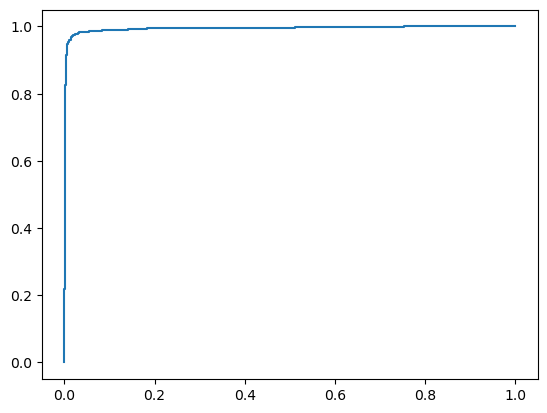

In [44]:
fpr, tpr, thresh = roc_curve(y_validation, y_pred)
plt.plot(fpr, tpr)

In [45]:
accuracy = accuracy_score(y_validation, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [46]:
class_report = classification_report(y_validation, y_pred)
print("Classification Report:\n", class_report)

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
parameter_space = {
    'hidden_layer_sizes': [(10,30,10),(20,)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}

gs = GridSearchCV(mlp, parameter_space, cv=5)

In [ ]:
gs.fit(x_train, y_train)
gs.best_params_
#12 minutes
#l'ho rifatto senza cambiare nulla e l'activation e alpha sono cambiati (?)

c:\Users\albad\.conda\envs\astr\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:693: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [ ]:
mlp = MLPClassifier(activation="tanh", hidden_layer_sizes=(10, 30, 10), max_iter=1000, alpha=0.0001, learning_rate="constant", solver="adam", random_state=42)

In [ ]:
mlp.fit(x_train, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=(10, 30, 10), max_iter=1000,
              random_state=42)

In [ ]:
y_pred = mlp.predict_proba(x_validation)[:,1]

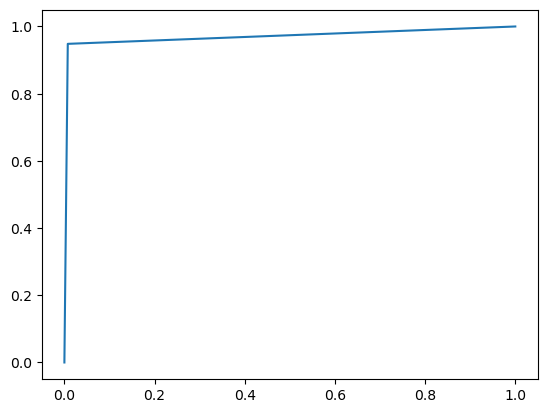

In [ ]:
fpr, tpr, thresh = roc_curve(y_validation, y_pred)
plt.plot(fpr, tpr)

In [ ]:
accuracy = accuracy_score(y_validation, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")
#l'accuratezza è addirittura diminuita (?)

Accuracy: 98.60%


In [ ]:
class_report = classification_report(y_validation, y_pred)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      8530
         1.0       0.96      0.95      0.95      1470

    accuracy                           0.99     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.99      0.99      0.99     10000

